In [4]:
# VERSIONE FINALE
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

LIGHT = "#E9E0FF"
DARK = "#caa5f1"
CMAP = LinearSegmentedColormap.from_list("lavender_purple", [LIGHT, DARK])

DATA_PATH = Path("/Users/federico/Desktop/progetto VIS/1. analisi ricerche-paper/01_openalex_trend.csv")
df = pd.read_csv(DATA_PATH)

def plot_growth(dframe, first_year, last_year, title, top_n=10, med_field="Medicine"):
    d = dframe[dframe["year"].between(first_year, last_year)]
    first = d[d["year"] == first_year].set_index("field_name")["works_count"]
    last = d[d["year"] == last_year].set_index("field_name")["works_count"]
    g = (last - first).fillna(0).sort_values(ascending=False)
    fields = g.head(top_n).index.tolist()
    if med_field not in fields:
        fields = [med_field] + fields[:-1]
    plot_df = g.loc[fields].sort_values()

    norm = plt.Normalize(plot_df.min(), plot_df.max())
    colors = CMAP(norm(plot_df.values))

    plt.figure(figsize=(8.5, 5.2))
    plt.barh(plot_df.index, plot_df.values, color=colors)
    plt.title(title, pad=10)
    plt.xlabel("Incremento pubblicazioni")
    plt.ylabel("Settore")

    for i, v in enumerate(plot_df.values):
        plt.text(v * 1.01, i, f"{int(v):,}".replace(",", "."), va="center", fontsize=9, color="#4B2C6F")

    ax = plt.gca()
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False)
    ax.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

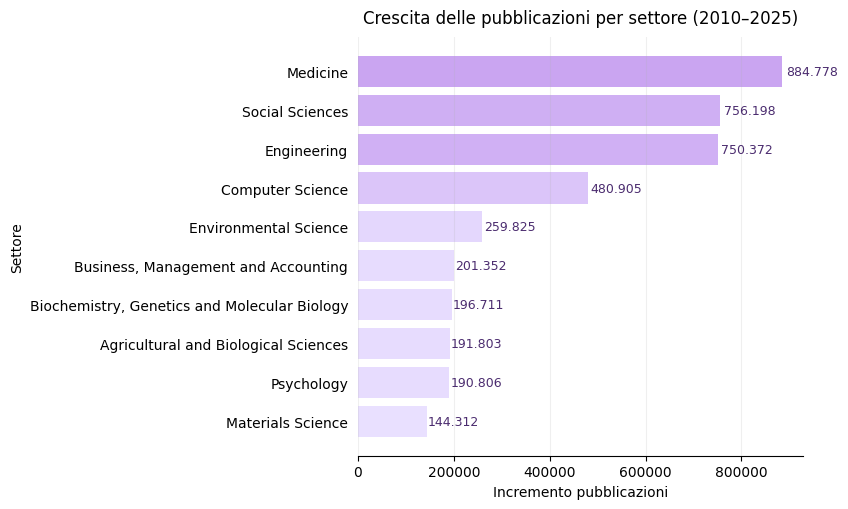

In [5]:
plot_growth(
    df,
    df["year"].min(),
    df["year"].max(),
    "Crescita delle pubblicazioni per settore (2010–2025)"
)

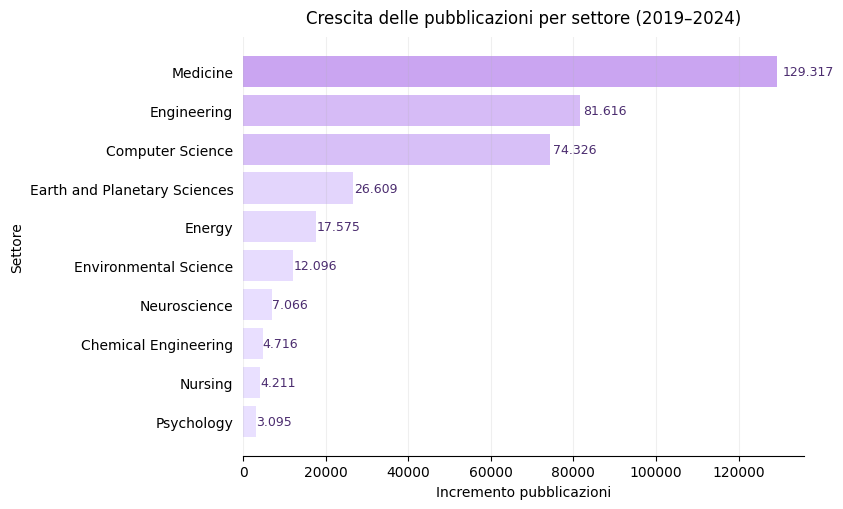

In [6]:
plot_growth(
    df,
    2019,
    2024,
    "Crescita delle pubblicazioni per settore (2019–2024)"
)